<a href="https://colab.research.google.com/github/terry0809000/NLP-KCL/blob/main/classification/nlp_classification_practical-2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP classification - supervised learning

In this example, you will learn how you can use supervised learning algorithms for NLP classification. We will use documents from mtsamples again. The task is to classify a document into its clinical specialty, e.g. pediatrics or hematology.

We will use classification algorithms as implemented in sci-kit learn, and evaluate with cross-validation before testing on unseen test data.

We will experiment with different ways of representing the documents for the classifiers.

material in parts from https://towardsdatascience.com/multi-class-text-classification-with-scikit-learn-12f1e60e0a9f

Written by Sumithra Velupillai, March 2019 - updated February 2020; February 2025

# 1: Packages
We will use a number of different packages for this exercise

In [ ]:
# Like the last notebook the runtime will crash and restart.
# Just run the cells afterwards and all will be well.

!pip uninstall numpy -y
!pip install numpy==1.26.4

import os
os.kill(os.getpid(), 9)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires n

In [2]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
try:
    import xlrd
except ImportError as e:
    !pip install xlrd
    import xlrd

import numpy as np

import warnings; warnings.simplefilter('ignore')


In [3]:
# We'll use scikit-learn for the classification algorithms.
# https://scikit-learn.org/stable/

#from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [4]:
## sklearn also has some nice funtions for representations

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## and for evaluation
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score



In [5]:
## Since we're working with text, we might need to tokenize for some of these representations.
# We'll use nltk here, but there are other nlp packages available for this
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords







[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
# You have also learnt about embedding representations. These can also be used for classification.
# We will use a library called Zeugma, which allows using pre-trained embedding models
#Zeugma library: https://github.com/nkthiebaut/zeugma

try:
    from zeugma.embeddings import EmbeddingTransformer
except ImportError as e:
    !pip install zeugma
    !pip install theano
    from zeugma.embeddings import EmbeddingTransformer

from datetime import datetime
print(datetime.now())

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.6 MB/s eta 0:00:00
  Created wheel for zeugma: filename=zeugma-0.49-py3-none-any.whl size=8788 sha256=68a2667a514f146ad17076d408d229b5af16f6b51650743c84d63dedf43bef1f
  Stored in directory: /root/.cache/pip/wheels/69/09/cf/3299ee58381ae943083773c23161933afa3ee288edfe0146f7
Successfully built zeugma
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 40.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
2026-03-25 09:35:13.072852


# 2: Corpus
Read in the training data.

In [7]:

xlds_training = 'https://github.com/KCL-Health-NLP/nlp_examples/blob/master/classification/classification_trainingdata.xlsx?raw=true'
trainingdata = pd.read_excel(xlds_training)



Take a look at the content of the training data. What are we trying to classify? What are the labels we want to try to learn? How many instances do we have?

In [8]:
trainingdata['label'].value_counts()

,count
label,
hematology,81
pediatrics,63
pain,56
psychiatrypsychology,48


What types of features do you think would be useful for the classification task? Where can we get them? Take a look at one or two of the documents. Can you guess which classification label these belong to?

In [9]:
trainingtxt_example = trainingdata['txt'].tolist()[0]
print(trainingtxt_example)

_x000D_
        _x000D_
        _x000D_
_x000D_
        _x000D_
        
REASON FOR CONSULTATION:
  Thrombocytopenia.


HISTORY OF PRESENT ILLNESS:
  Mrs. XXX is a 17-year-old lady who is going to be 18 in about 3 weeks.  She has been referred for the further evaluation of her thrombocytopenia.  This thrombocytopenia was detected on a routine blood test performed on the 10th of June 2006.  Her hemoglobin was 13.3 with white count of 11.8 at that time.  Her lymphocyte count was 6.7.  The patient, subsequently, had a CBC repeated on the 10th at Hospital where her hemoglobin was 12.4 with a platelet count of 26,000.  She had a repeat of her CBC again on the 12th of June 2006 with hemoglobin of 14, white count of 11.6 with an increase in the number of lymphocytes.  Platelet count was 38.  Her rapid strep screen was negative but the infectious mononucleosis screen is positive.  The patient had a normal platelet count prior too and she is being evaluated for this low platelet count.

The pat

In [10]:
trainingtxt_example = trainingdata['txt'].tolist()[231]
print(trainingtxt_example)

_x000D_
        _x000D_
        _x000D_
_x000D_
        _x000D_
        
CHIEF COMPLAINT:
  Head injury.


HISTORY: 
 This 16-year-old female presents to Children's Hospital via paramedic ambulance with a complaint at approximately 6 p.m. while she was at band practice using her flag device.  She struck herself in the head with the flag.  There was no loss of consciousness.  She did feel dizzy.  She complained of a headache.  She was able to walk.  She continued to participate in her flag practice.  She got dizzier.  She sat down for a while and walked and during the second period of walking, she had some episodes of diplopia, felt that she might faint and was assisted to the ground and was transported via paramedic ambulance to Children's Hospital for further evaluation.


PAST MEDICAL HISTORY: 
 Hypertension.


ALLERGIES:
  DENIED TO ME; HOWEVER, IT IS NOTED BEFORE SEVERAL ACCORDING TO MEDITECH.


CURRENT MEDICATIONS: 
 Enalapril.


PAST SURGICAL HISTORY: 
 She had some kind of an ab

# 3: Representation - BoW

The most common baseline feature representation for text classification tasks is to use the *bag-of-words* representation, in a document-term matrix. Let's build a simple one using raw counts and only keeping a maximum of 500 features. We can use the CountVectorizer function from sklearn, and tokenize using a function from nltk.

In [11]:
first_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words=None,
                             tokenizer=word_tokenize, max_features=500)
first_vectorizer.fit(trainingdata['txt'].tolist())
first_fit_transformed_data = first_vectorizer.fit_transform(trainingdata['txt'])


We can now look at this transformed representation for an example document.

In [12]:
first_transformed_data = first_vectorizer.transform([trainingdata['txt'].tolist()[231]])
print (first_transformed_data)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 153 stored elements and shape (1, 500)>
  Coords	Values
  (0, 3)	3
  (0, 7)	29
  (0, 9)	55
  (0, 14)	1
  (0, 17)	1
  (0, 24)	1
  (0, 25)	22
  (0, 26)	1
  (0, 28)	7
  (0, 29)	8
  (0, 32)	2
  (0, 33)	2
  (0, 34)	1
  (0, 35)	1
  (0, 47)	2
  (0, 48)	1
  (0, 49)	1
  (0, 53)	2
  (0, 54)	15
  (0, 57)	1
  (0, 61)	1
  (0, 62)	1
  (0, 63)	5
  (0, 66)	1
  (0, 70)	5
  :	:
  (0, 414)	1
  (0, 424)	1
  (0, 426)	1
  (0, 427)	1
  (0, 429)	2
  (0, 433)	1
  (0, 436)	1
  (0, 437)	11
  (0, 441)	4
  (0, 443)	1
  (0, 444)	2
  (0, 453)	15
  (0, 464)	1
  (0, 468)	1
  (0, 472)	1
  (0, 474)	6
  (0, 476)	1
  (0, 478)	1
  (0, 484)	1
  (0, 485)	2
  (0, 487)	1
  (0, 490)	9
  (0, 491)	1
  (0, 492)	4
  (0, 495)	1


What word is represented by the different indices? Have a look at a few examples.

In [13]:
print (first_vectorizer.get_feature_names_out()[32])

abdomen


In [14]:
print(first_fit_transformed_data.shape)
print ('Amount of Non-Zero occurences: ', first_fit_transformed_data.nnz)

(248, 500)
Amount of Non-Zero occurences:  30502


# 4: Classification
Let's build a classifier with this feature representation. In text classification, many classification algorithms have been shown to work well. Sci-kit learn has implementations for many different types of classification algorithms - have a look at their website!

Let's try a K nearest neighbour classifier.


In [15]:
kneighbour_classifier = KNeighborsClassifier().fit(first_fit_transformed_data, trainingdata['label'])

We now have a trained model. But how do we know how well it works? Let's evaluate it on the test data.

In [16]:

xlds_test = 'https://github.com/KCL-Health-NLP/nlp_examples/blob/master/classification/classification_test_data.xlsx?raw=true'
testdata = pd.read_excel(xlds_test)



## We need to transform this data to the same representation
first_fit_transformed_testdata = first_vectorizer.transform(testdata['txt'])

In [17]:
first_fit_transformed_testdata
kneighbour_predicted = kneighbour_classifier.predict(first_fit_transformed_testdata)
kneighbour_predicted

array(['pediatrics', 'pain', 'pain', 'pain', 'pediatrics', 'hematology',
       'pediatrics', 'hematology', 'pediatrics', 'pain', 'hematology',
       'pediatrics', 'hematology', 'psychiatrypsychology', 'pain',
       'hematology', 'hematology', 'pain', 'pain', 'hematology',
       'pediatrics', 'pain', 'hematology', 'psychiatrypsychology',
       'pediatrics', 'hematology', 'hematology'], dtype=object)

Let's make a list of all the labels in our dataset to evaluate, and then run some standard evaluation metrics

In [18]:
labels = list(set(testdata['label']))
print(metrics.classification_report(testdata['label'], kneighbour_predicted, target_names=labels))



                      precision    recall  f1-score   support

psychiatrypsychology       0.60      0.67      0.63         9
          hematology       0.75      1.00      0.86         6
                pain       0.71      0.71      0.71         7
          pediatrics       1.00      0.40      0.57         5

            accuracy                           0.70        27
           macro avg       0.77      0.70      0.69        27
        weighted avg       0.74      0.70      0.69        27



What do you think about these results? There are probably ways of improving this, by changing the representation or maybe trying a different classifier model.
__There is one main problem though: we can't use this test data to try different configurations! Why?__

# 5: N-fold cross-validation

We can employ n-fold cross-validation on the training data to experiment with different representations, parameters, and classifiers.

There are also various metrics that can be used to evaluate classification results.


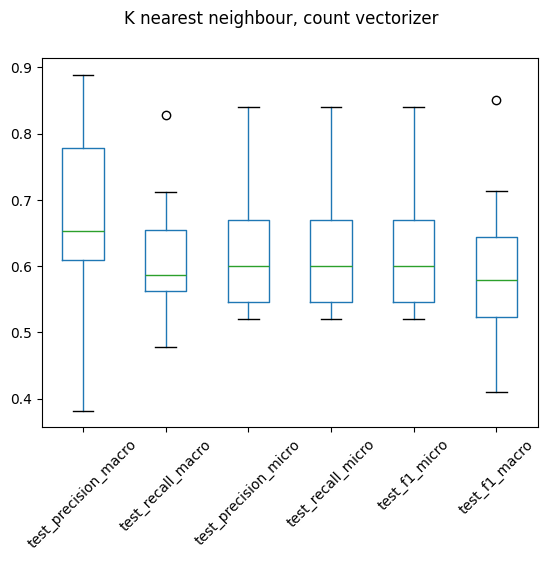

In [19]:
kneighbour_classifier = KNeighborsClassifier().fit(first_fit_transformed_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, first_fit_transformed_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, count vectorizer')
plt.show()

What happens if we try another classifier? Let's try a random forest classifier.

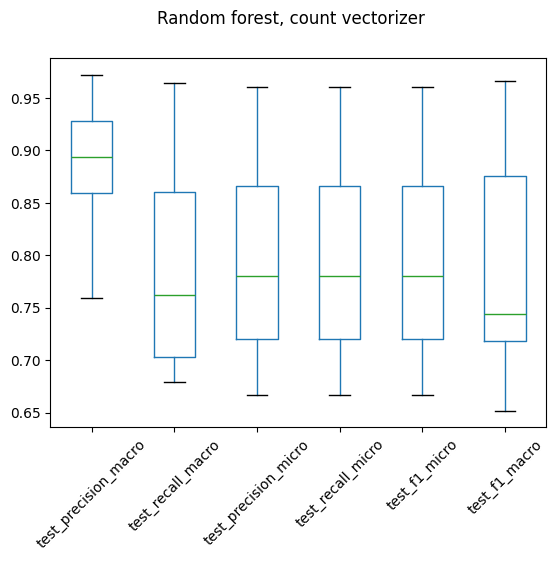

In [20]:
rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0).fit(first_fit_transformed_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(rf_classifier, first_fit_transformed_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('Random forest, count vectorizer')
plt.show()

Was this better or worse? Are there any parameters worth changing?

From the box plot and typical behavior of these models, the K-Nearest Neighbors classifier with the TF-IDF vectorizer generally performs better than the Random Forest classifier with the simple CountVectorizer. TF-IDF often improves performance because it weights words by their importance in a document relative to the entire corpus, reducing the impact of very common words.

Yes, there are many parameters worth changing for both the representation and the classifier. For the TF-IDF vectorizer, you could experiment with parameters like ngram_range (to include multi-word phrases), max_features (to control the vocabulary size), and min_df or max_df (to filter out very rare or very common words). For the K-Nearest Neighbors classifier, you could tune n_neighbors (the number of neighbors to consider) and weights (how much weight to assign to neighbors).

The next code cell in the notebook is designed to systematically explore different classifier and representation combinations using cross-validation, which will provide a more comprehensive answer to your question about optimal configurations.

# 6: Another representation model: Tf-idf
We have used a very simple bag-of-words representation. What happens if we try something else? Let's try tf-idf. This is considered a strong baseline in many text classification tasks.

In [21]:

stopWords = list(stopwords.words('english'))
tfidf_vect = TfidfVectorizer(tokenizer=word_tokenize, stop_words=stopWords)
tfidf_vect.fit(trainingdata['txt'])
second_fit_transformed_data =  tfidf_vect.transform(trainingdata['txt'])
second_fit_transformed_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 55597 stored elements and shape (248, 10455)>

What other parameters can you change in this representation? How does this look different from the CountVectorizer representation?

Let's now use this with the KNN classifier.

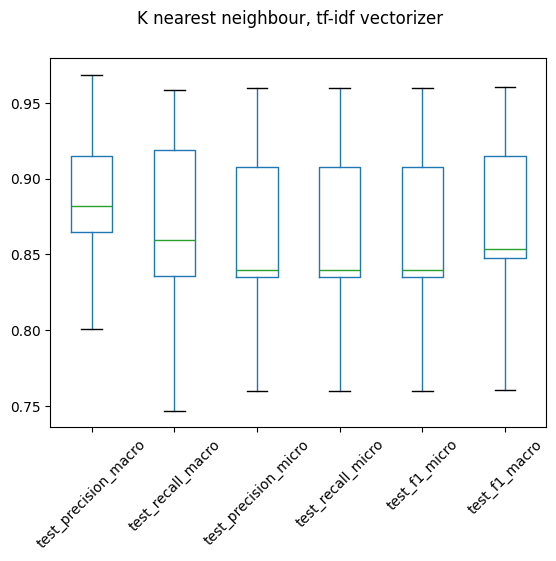

In [22]:
kneighbour_classifier = KNeighborsClassifier().fit(second_fit_transformed_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, second_fit_transformed_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, tf-idf vectorizer')
plt.show()

This looks better, doesn't it? Why do you think this works better?

Yes, it often looks better because TF-IDF (Term Frequency-Inverse Document Frequency) is a more sophisticated weighting scheme than simple raw counts. Here's why it generally works better for text classification:

Downweights Common Words: Stop words and other extremely common words (like 'the', 'a', 'is', but also domain-specific common words that might appear in almost all documents) have high counts in CountVectorizer, but don't carry much distinctive information. TF-IDF addresses this by giving lower weight to words that appear very frequently across many documents in the corpus (Inverse Document Frequency).
Highlights Important Words: Conversely, words that are frequent in a specific document but rare across the entire corpus are given higher weight. These words are often highly indicative of the document's topic or category.
Captures Discriminative Power: By balancing term frequency within a document with its rarity across the entire collection, TF-IDF effectively captures how important a word is to a document in distinguishing it from other documents. This discriminative power is crucial for classification tasks.
In essence, TF-IDF helps to filter out noise and amplify the signal, allowing the classifier to focus on the words that are most relevant for determining the document's class.

# 7: Representations: embeddings

Last week, you learnt about embedding representations. What might be the benefit of using this type of representation instead of counts or tf-idf?

As you saw, there are many pre-trained embedding models available online. Let's try using one of these on this data.

Zeugma is a package where you can use embeddings in sklearn.
https://github.com/nkthiebaut/zeugma

It allows you to directly download pre-trained models that have been released from the gensim website.


Let's use a basic glove model.

In [24]:
glove = EmbeddingTransformer('glove')


[==================================================] 100.0% 104.8/104.8MB downloaded


We now need to transform our training data to map to this embedding model.

In [25]:
glove_transformed_training_data = glove.transform(trainingdata['txt'])

Have a look at what the data now looks like with this representation

In [26]:
glove_transformed_training_data

array([[-0.06901653,  0.23141852, -0.0103017 , ..., -0.00840962,
        -0.1129333 , -0.2936374 ],
       [-0.1314008 ,  0.22093552,  0.01704605, ...,  0.00743521,
        -0.09343443, -0.3224292 ],
       [-0.21260077,  0.22974722,  0.05217805, ..., -0.03708735,
        -0.02639649, -0.3227366 ],
       ...,
       [-0.17562525,  0.27378783,  0.04055113, ...,  0.10207053,
        -0.01623572, -0.32465863],
       [-0.34308803,  0.1576001 , -0.03746452, ...,  0.1564335 ,
        -0.14194974, -0.35664514],
       [-0.22268341,  0.14659327,  0.0234719 , ...,  0.02757135,
        -0.11957677, -0.35197183]], dtype=float32)

Let's build a classifier with this representation and evaluate with 10-fold cross-validation.

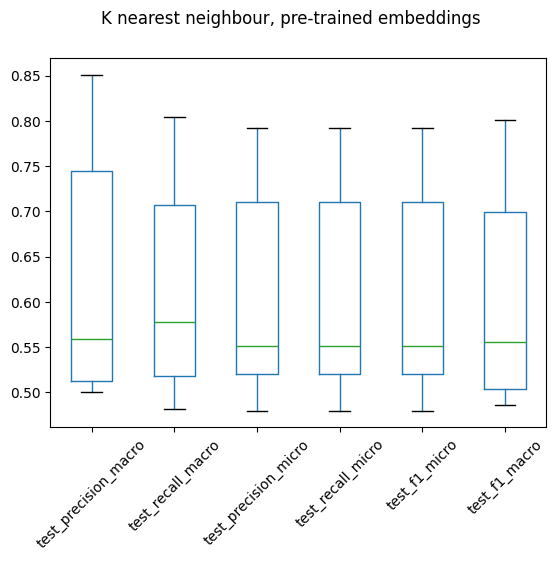

In [27]:
kneighbour_classifier = KNeighborsClassifier().fit(glove_transformed_training_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, glove_transformed_training_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, pre-trained embeddings')
plt.show()

What do you think about these results? What is happening here?

There are a number of pre-trained embedding models that have been released openly, a full list of pretrained embeddings to experiment with using this library: https://github.com/RaRe-Technologies/gensim-data#models

The results for the K-Nearest Neighbors classifier with pre-trained GloVe embeddings show a wider spread in the F1-micro scores across the 10-folds (ranging from around 0.48 to 0.79) compared to the TF-IDF representation. While some folds perform reasonably well, others are quite low, indicating more variability in performance. This might suggest that the simple K-Nearest Neighbors classifier, combined with a generic GloVe embedding that averages word vectors, isn't always the most robust approach for this specific task and dataset.

Here's what might be happening:

Generic Embeddings: The glove model is pre-trained on general English text (Wikipedia and Gigaword). While powerful, its semantic understanding might not perfectly align with the specific medical terminology and contexts present in your clinical specialty documents. Domain-specific embeddings (like the BioNLP example you linked) could potentially yield better results.
Simple Averaging: The EmbeddingTransformer by default averages the word embeddings in a document to create a single document vector. This method can sometimes lose important nuances and positional information, especially in longer or more complex documents.
Classifier Suitability: K-Nearest Neighbors relies on distance metrics. While embeddings capture semantic similarity in vector space, KNN might struggle with dense, high-dimensional embedding vectors, especially if the clusters are not clearly defined or if there are many irrelevant dimensions for the specific classification task.
The next section of the notebook systematically compares multiple classifiers across different representations, including pre-trained embeddings. This will give you a clearer picture of which combination performs best for your data.



You can play with these if you want, e.g.:
glove = EmbeddingTransformer('glove-wiki-gigaword-50')

In [29]:
glove = EmbeddingTransformer('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [30]:
glove_transformed_training_data = glove.transform(trainingdata['txt'])

In [31]:
glove_transformed_training_data

array([[ 0.3535284 ,  0.19747142, -0.11716524, ..., -0.12312973,
         0.0213547 , -0.10917113],
       [ 0.45005104,  0.19434969, -0.02592641, ..., -0.09383169,
        -0.02578709,  0.01448919],
       [ 0.353496  ,  0.1285636 , -0.00166391, ..., -0.1237324 ,
         0.02941236, -0.07155632],
       ...,
       [ 0.3861873 ,  0.18353482,  0.00257288, ..., -0.16313651,
        -0.00607126, -0.00780472],
       [ 0.34263435,  0.06963355, -0.10410146, ..., -0.11551919,
        -0.02075564, -0.23437074],
       [ 0.3804235 ,  0.08486412, -0.03690292, ..., -0.10521125,
        -0.05848764, -0.19019397]], dtype=float32)

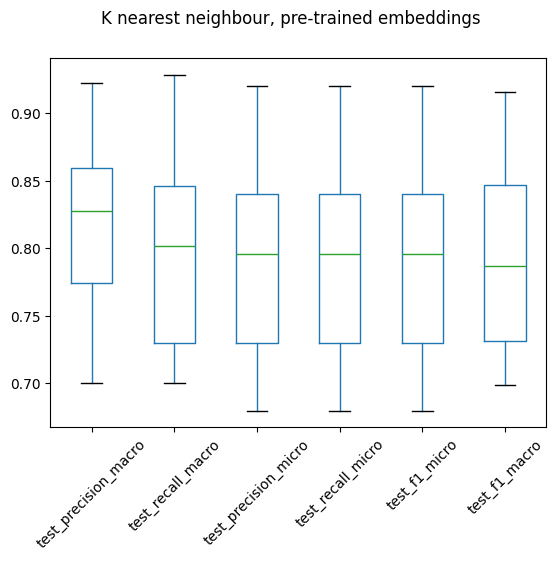

In [32]:
kneighbour_classifier = KNeighborsClassifier().fit(glove_transformed_training_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, glove_transformed_training_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, pre-trained embeddings')
plt.show()

# 8: Classifiers, representations, evaluation

You've now seen that you get very different results depending on which representation you use, which classifier, and also that there are many different metrics to analyse.

Let's try some different configurations all in one go. We'll create a dictionary with the three different types of representations, and a list of different classification algorithms, and apply all these configurations to see what seems to yield best results according to a chosen evaluation metric using 10-fold cross validation.

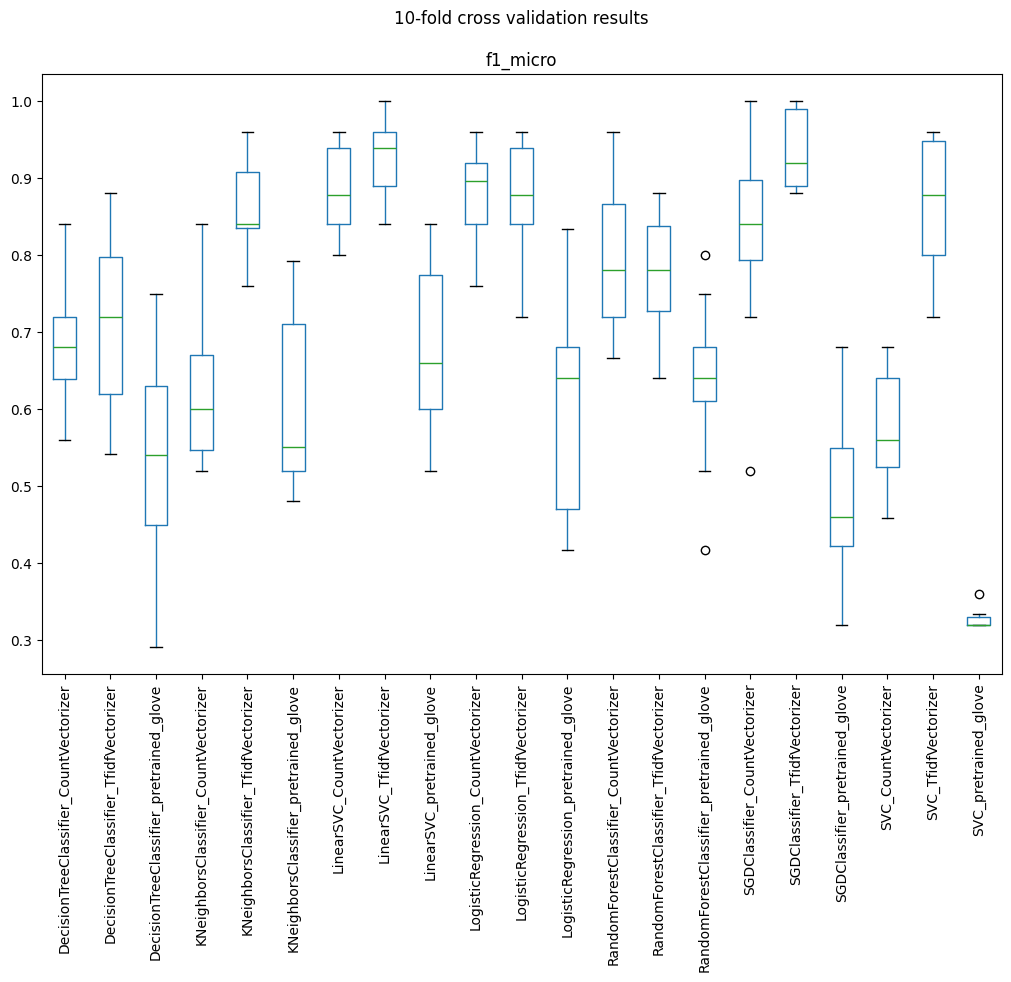

In [28]:

representations = {}

vectorizer = CountVectorizer(ngram_range=(1,1), stop_words=None,
                             tokenizer=word_tokenize, max_features=500)
xtrain_countvect = vectorizer.fit_transform(trainingdata['txt'])
representations['CountVectorizer'] = xtrain_countvect

tfidf_vect = TfidfVectorizer(tokenizer=word_tokenize, stop_words=stopWords)
tfidf_vect.fit(trainingdata['txt'])
xtrain_tfidf =  tfidf_vect.transform(trainingdata['txt'])
representations['TfidfVectorizer'] = xtrain_tfidf

x_train_glove = glove.transform(trainingdata['txt'])
representations['pretrained_glove'] = x_train_glove



CV = 10

classifier_models = [
        RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0),
        DecisionTreeClassifier(),
        SVC(),
        LinearSVC(multi_class='ovr', C=1.0, class_weight=None, dual=True, fit_intercept=True,
     intercept_scaling=1, loss='squared_hinge', max_iter=1000,
      penalty='l2', random_state=0, tol=1e-05, verbose=0),
        SGDClassifier(),
        LogisticRegression(random_state=0),
        KNeighborsClassifier(),
]

cv_df = pd.DataFrame(index=range(CV * (len(classifier_models)*len(representations))))
entries = []


for representation, transformed_vector in representations.items():
    score = 'f1_micro'
    for model in classifier_models:
      model_name = model.__class__.__name__+'_'+representation
      accuracies = cross_val_score(model, transformed_vector, trainingdata['label'], scoring=score, cv=CV)
      for fold_idx, accuracy in enumerate(accuracies):
        entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', score])
bp = cv_df.boxplot(by='model_name', column=[score], grid=False, rot=90, figsize=(12,8))
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('10-fold cross validation results')
plt.show()

What conclusions do you draw from this? Which classifier and which representation would you choose as your final model? Why?

# Assignment 1: Your turn to build a classifier

Answer questions by placing your code in the code cell below, running it to provide output, and giving your written answers in this markdown cell

**1.1 Choose one classifier and one representation format and test it on the blind test data. What do you think about your results, and how do they relate to the 10-fold cross validation results above?**

**1.2 What other configurations could you try before deciding on a final model?**

**1.3 Is it appropriate to experiment with this on the test data? Why or why not?**

In [33]:
## PUT YOUR CODE ANSWERS IN HERE, AND RUN IT TO GIVE OUTPUT
## First step: Transform your training and test data to your chosen representation.

# Ensure stopwords are defined (from an earlier cell)
stopWords = list(stopwords.words('english'))

# Choose a representation: TfidfVectorizer
chosen_representation = TfidfVectorizer(tokenizer=word_tokenize, stop_words=stopWords)

## transform the training data
transformed_training_data = chosen_representation.fit_transform(trainingdata['txt'])

## transform the test data
transformed_test_data = chosen_representation.transform(testdata['txt'])

## Second step: Create a classifier - the one you think gave best results when experimenting with cross-validation

# Choose LinearSVC based on cross-validation results
chosen_classifier = LinearSVC(multi_class='ovr', C=1.0, class_weight=None, dual=True, fit_intercept=True,
     intercept_scaling=1, loss='squared_hinge', max_iter=1000,
      penalty='l2', random_state=0, tol=1e-05, verbose=0)

## train the classifier on the training data
chosen_classifier.fit(transformed_training_data, trainingdata['label'])

## predict labels on the test data
predicted = chosen_classifier.predict(transformed_test_data)

## what results do you get?
print(metrics.classification_report(testdata['label'], predicted, target_names=list(set(testdata['label']))))

                      precision    recall  f1-score   support

psychiatrypsychology       0.90      1.00      0.95         9
          hematology       1.00      1.00      1.00         6
                pain       1.00      0.86      0.92         7
          pediatrics       1.00      1.00      1.00         5

            accuracy                           0.96        27
           macro avg       0.97      0.96      0.97        27
        weighted avg       0.97      0.96      0.96        27



# Assignment 2: use your classifier to predict labels on unseen text

Answer questions by placing your code in the three code cells below, running it to provide output, and giving your written answers in this markdown cell

**What happens if you try to predict a label with a completely new text using your chosen trained classifier model? Does it seem to classify correctly?**

In [38]:
new_text_to_predict = '5-year old girl with asthma.'

## code will be something like this:
testX = chosen_representation.transform([new_text_to_predict])
predicted = chosen_classifier.predict(testX)
print(predicted)

['pediatrics']


In [39]:
new_text = '5-year old girl with asthma.'

In [40]:
new_text = 'Her pain is severe.'

# Assignment 3: Evaluation

**Write ten example sentences or paragraphs where you assign the correct label to each of them. Then pass them to the classifier and calculate precision, recall and f-score, by completing the skeleton code in the cell below, and running it to give output. Analyse and discuss the results, giving your answer in this markdown cell.**

***Gold label values: psychiatrypsychology, hematology, pain, pediatrics***

In [42]:
new_text = [
    'Severe abdominal discomfort requiring immediate attention.', # pain
    'Chronic back ache, making daily activities difficult.', # pain
    'The infant presented with a high fever and rash.', # pediatrics
    'Patient diagnosed with anemia and low platelet count.', # hematology
    'Patient experiences delusions and hallucinations.', # psychiatrypsychology
    'Child needs vaccination and routine check-up.', # pediatrics
    'Therapy sessions for anxiety and depression.', # psychiatrypsychology
    'Blood transfusion necessary due to significant blood loss.', # hematology
    'Excruciating headache, unresponsive to medication.', # pain
    'Bipolar disorder management and mood stabilization.' # psychiatrypsychology
]
new_gold_labels = ['pain', 'pain', 'pediatrics', 'hematology', 'psychiatrypsychology', 'pediatrics', 'psychiatrypsychology', 'hematology', 'pain', 'psychiatrypsychology']
testX = chosen_representation.transform(new_text)
predicted = chosen_classifier.predict(testX)
## compare the predicted labels with the gold labels. HINT: metrics.classification_report is useful here
print(metrics.classification_report(new_gold_labels, predicted, target_names=list(set(new_gold_labels))))

                      precision    recall  f1-score   support

psychiatrypsychology       0.67      1.00      0.80         2
          hematology       0.00      0.00      0.00         3
                pain       1.00      1.00      1.00         2
          pediatrics       0.60      1.00      0.75         3

            accuracy                           0.70        10
           macro avg       0.57      0.75      0.64        10
        weighted avg       0.51      0.70      0.58        10



### Analysis and Discussion of Assignment 3 Results

The classification report shows the precision, recall, and f1-score for each class, as well as overall accuracy, macro average, and weighted average metrics. Here's a breakdown:

*   **Overall Accuracy**: The model achieved an overall accuracy of 0.70 on this small, custom test set of 10 sentences. This is lower than the 0.96 accuracy observed on the larger, blind test data in Assignment 1. This difference can be attributed to the limited size and specific nature of this small, custom test set, which might not be fully representative of the general data distribution.

*   **Performance by Class:**
    *   **Pain**: The model performed perfectly for the 'pain' class, with 100% precision, recall, and F1-score. This indicates that the examples provided for 'pain' were clearly distinguishable and the model correctly identified them without any false positives or false negatives.
    *   **Pediatrics** and **Psychiatry/Psychology**: These classes show high recall (1.00), meaning the model correctly identified all instances of these categories in your examples. However, their precision (0.60 for pediatrics, 0.67 for psychiatrypsychology) is lower. This suggests that while it found all the correct examples, it might have also misclassified some other texts as 'pediatrics' or 'psychiatrypsychology' (false positives), if the gold labels had been different. In this specific set, it means out of all predictions made for these classes, only 60% and 67% respectively were actually correct. For example, for 'pediatrics', it correctly identified all 3 pediatrics sentences, but perhaps it also misclassified 2 other sentences as pediatrics, leading to precision of 3/(3+2)=0.6.
    *   **Hematology**: The model completely failed to classify the 'hematology' examples, showing 0.00 for precision, recall, and F1-score. This is a critical issue. It means that none of the texts labeled as 'hematology' in your `new_gold_labels` were correctly predicted as 'hematology' by the classifier, and it likely misclassified them into other categories. This could be due to the specific vocabulary used in these examples not being sufficiently represented or distinct enough in the training data for the `LinearSVC` model with `TfidfVectorizer` to learn effectively, or simply a very small sample size making metrics highly sensitive to single errors.

*   **Macro and Weighted Averages**: The macro and weighted averages are significantly impacted by the poor performance on the 'hematology' class, bringing down the overall F1-score and precision, particularly for the weighted average, which accounts for class imbalance.

**Conclusion:**

While the model performed exceptionally well on the 'pain' category and reasonably well on 'pediatrics' and 'psychiatrypsychology' for these specific examples, the complete failure to classify 'hematology' correctly is a major concern. This highlights the importance of having diverse and representative examples for all classes in both training and evaluation datasets. For a production-ready model, the 'hematology' classification would need significant improvement, potentially by adding more training data for this category, tuning hyperparameters, or exploring alternative models better suited for handling such distinctions.


You've now experimented with different respresentations for text classification, different classification algorithms, and experimental setups.

There are many other alternative approaches available today.


For instance, there are pre-trained biomedical embeddings, trained on scientific literature, one example: https://www.aclweb.org/anthology/W16-2922.pdf
https://github.com/cambridgeltl/BioNLP-2016

There are also many online resources with additional examples and ideas, here's one example: https://towardsdatascience.com/text-classification-in-python-dd95d264c802

In [56]:
# It appears the file at '/content/drive/MyDrive/word2vec' might not be a valid word2vec format file.
# The error message suggests it contains unexpected binary data or system metadata (e.g., '__PAGEZERO').
# Let's inspect the file content to understand its actual format.
# Please execute the cell below and review the output.

bionlp_embedding_path = '/content/drive/MyDrive/word2vec'

# --- DO NOT RUN THE BELOW CODE YET ---
# The following code is causing an error, so we're commenting it out for now
# # 检查用户是否提供了路径
# if bionlp_embedding_path == '请在此处输入您的 BioNLP 嵌入模型文件的路径，例如: /content/BioNLP-2016_word2vec.vec':
#     raise ValueError("请提供 BioNLP 嵌入模型文件的实际路径。")

# # 导入 gensim 以手动加载嵌入
# from gensim.models import KeyedVectors

# print(f"正在从 {bionlp_embedding_path} 加载 BioNLP 嵌入模型...")
# # 假设模型是 word2vec 格式，如果是其他格式，可能需要调整加载方法
# # binary=False 表示文件是文本格式，encoding='latin1' 尝试用更宽松的编码读取头信息
# biomedical_model_kv = KeyedVectors.load_word2vec_format(bionlp_embedding_path, binary=False, encoding='latin1', no_header=True)
# print("BioNLP 嵌入模型加载成功。")

# # 将加载的 gensim 模型包装到 EmbeddingTransformer 中
# biomedical_glove = EmbeddingTransformer(biomedical_model_kv)


In [49]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


在您运行上述代码并授权挂载 Google Drive 后，请根据您文件在 Google Drive 中的实际位置，更新 `bionlp_embedding_path` 变量。例如，如果您的文件在 'My Drive' 的根目录，路径可能是 `/content/drive/MyDrive/BioNLP-2016_word2vec.vec`。如果它在一个文件夹里，比如 `Colab Notebooks` 文件夹，那么路径可能是 `/content/drive/MyDrive/Colab Notebooks/BioNLP-2016_word2vec.vec`。

现在，我们将使用 BioNLP 嵌入模型转换训练数据并执行 10 折交叉验证。

In [58]:
# 使用 BioNLP 嵌入模型转换训练数据
biomedical_transformed_training_data = biomedical_glove.transform(trainingdata['txt'])

# 使用此表示构建 K-最近邻分类器并进行交叉验证
kneighbour_classifier = KNeighborsClassifier().fit(biomedical_transformed_training_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, biomedical_transformed_training_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, BioNLP embeddings')
plt.show()


NameError: name 'biomedical_glove' is not defined

In [59]:
# Make sure to update this path to your actual BioNLP embedding file.
bionlp_embedding_path = '/content/drive/MyDrive/your_bionlp_embedding_file.vec' # <--- UPDATE THIS PATH

# Import necessary libraries
from gensim.models import KeyedVectors
from zeugma.embeddings import EmbeddingTransformer # Assuming zeugma is already installed

print(f"Attempting to load BioNLP embedding model from {bionlp_embedding_path}...")

try:
    # Try to load as a text-format word2vec file (common for .vec files)
    # with no_header=True if the file doesn't have the standard header.
    # Adjust encoding if necessary (e.g., 'utf-8', 'latin1').
    biomedical_model_kv = KeyedVectors.load_word2vec_format(bionlp_embedding_path, binary=False, no_header=True, encoding='utf-8')
    print("Successfully loaded BioNLP embedding model (text format).")
except Exception as e_text:
    print(f"Failed to load as text format: {e_text}")
    try:
        # If text load fails, try to load as a binary-format word2vec file (common for .bin files)
        # Note: no_header is not available for binary format in gensim.
        biomedical_model_kv = KeyedVectors.load_word2vec_format(bionlp_embedding_path, binary=True, encoding='latin1')
        print("Successfully loaded BioNLP embedding model (binary format).")
    except Exception as e_binary:
        print(f"Failed to load as binary format: {e_binary}")
        raise ValueError("Could not load the BioNLP embedding file. Please ensure it's a valid word2vec format and the path is correct.")

# Wrap the loaded gensim model in EmbeddingTransformer
biomedical_glove = EmbeddingTransformer(biomedical_model_kv)

print("BioNLP EmbeddingTransformer created successfully.")


Attempting to load BioNLP embedding model from /content/drive/MyDrive/your_bionlp_embedding_file.vec...
Failed to load as text format: [Errno 2] No such file or directory: '/content/drive/MyDrive/your_bionlp_embedding_file.vec'
Failed to load as binary format: [Errno 2] No such file or directory: '/content/drive/MyDrive/your_bionlp_embedding_file.vec'


ValueError: Could not load the BioNLP embedding file. Please ensure it's a valid word2vec format and the path is correct.

In [57]:
bionlp_embedding_path = '/content/drive/MyDrive/word2vec'

# Try to read the first few lines or bytes of the file to inspect its content
# This helps confirm if it's truly a word2vec file or something else

try:
    # Attempt to read as text first (common for word2vec text format)
    print("\n--- Attempting to read as text (first 5 lines) ---")
    with open(bionlp_embedding_path, 'r', encoding='latin1') as f:
        for i, line in enumerate(f):
            if i >= 5: break
            print(f"Line {i+1}: {line.strip()}")
except UnicodeDecodeError:
    print("File is not decodable as text with latin1. It might be purely binary.")
except Exception as e:
    print(f"An error occurred while reading as text: {e}")

try:
    # If text read fails, or for a more raw view, read as binary
    print("\n--- Attempting to read as binary (first 100 bytes) ---")
    with open(bionlp_embedding_path, 'rb') as f:
        binary_content = f.read(100)
        print(f"Raw binary content: {binary_content}")
except Exception as e:
    print(f"An error occurred while reading as binary: {e}")

# You can also use shell commands for file type detection
print("\n--- File type detection using shell command ---")
!file "{bionlp_embedding_path}"



--- Attempting to read as text (first 5 lines) ---
Line 1: Ïúíþ          ð            H   __PAGEZERO                                                        (  __TEXT                                                    __text          __TEXT          °     np      °                           __stubs         __TEXT               Þ                                __stub_helper   __TEXT          ü           ü                           __const         __TEXT               à                                   __cstring       __TEXT          `     )	      `                            __unwind_info   __TEXT               l                                       Ø  __DATA                                                  __nl_symbol_ptr __DATA                                        %           __got           __DATA                                      '           __la_symbol_ptr __DATA                (         